In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import matplotlib.cm as cm
import qutip as qu
import sympy as sym

In [2]:
# Set font size of plot elements\n",
SMALL_SIZE = 12
MEDIUM_SIZE = 14
BIGGER_SIZE = 18
plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

In [3]:
g10, δ, Δ = sym.symbols("g_{10}, δ, Δ")

In [4]:
H1 = sym.Matrix([[0, g10, 0],
                 [g10, -Δ, 0],
                 [0, 0, δ]])
H1

Matrix([
[     0, g_{10}, 0],
[g_{10},     -Δ, 0],
[     0,      0, δ]])

In [5]:
H1.eigenvects()

[(δ,
  1,
  [Matrix([
   [0],
   [0],
   [1]])]),
 (-Δ/2 - sqrt(4*g_{10}**2 + Δ**2)/2,
  1,
  [Matrix([
   [Δ/g_{10} + (-Δ/2 - sqrt(4*g_{10}**2 + Δ**2)/2)/g_{10}],
   [                                                    1],
   [                                                    0]])]),
 (-Δ/2 + sqrt(4*g_{10}**2 + Δ**2)/2,
  1,
  [Matrix([
   [Δ/g_{10} + (-Δ/2 + sqrt(4*g_{10}**2 + Δ**2)/2)/g_{10}],
   [                                                    1],
   [                                                    0]])])]

In [6]:
g1 = 10
g2 = 1
ω = 5 + 1j*2
ω /= np.abs(ω)
d = 1

In [7]:
a = qu.destroy(2)
Ha = ω * a.dag() * a
Hb = d * a.dag() * a

In [8]:
Ha.eigenstates()

(array([0.        +0.j        , 0.92847669+0.37139068j]),
 array([Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
        Qobj data =
        [[1.]
         [0.]]                                                                ,
        Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
        Qobj data =
        [[0.]
         [1.]]                                                                ],
       dtype=object))

Kevin mentioned that it would be a good idea if we could demonstrate that the Green's function approach yields the bare cavity response in the limit of no atoms.  This should be something like a complex Lorentzian $\frac{1}{\omega-\omega_c}$.

In [9]:
# Define ωc
ωc = 5 + 1j*5

# Define detuning ω - ωc
δ = np.linspace(-20, 20, 100)
ωs = δ + 5

In [10]:
# Define Hamiltonian for cavity
a = qu.destroy(2)
Hc = ωc * a.dag() * a

# Get the eigenstates
Hc_eigs = Hc.eigenstates()

If there are no atoms and no driving term, then there's no perturbation of the cavity, so $V=0$.  Calculating the level shift function with $|\phi_b\rangle = |1\rangle$ therefore yields zero.  The transfer function is then just $G_{bb}(\omega) = \frac{1}{\omega-E_b}$ where $E_b$ is the eigenvalue of the eigenstate.

In [11]:
Hc_eigs[0][1]

np.complex128(5+5j)

In [12]:
# Calculate the transfer function
Gb = 1 / (ωs - Hc_eigs[0][1])

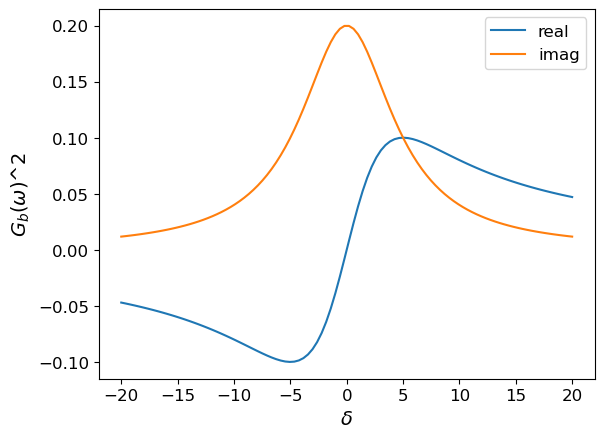

In [13]:
plt.plot(δ, Gb.real, label='real')
plt.plot(δ, Gb.imag, label='imag')
plt.xlabel("$\\delta$")
plt.ylabel("$G_b(\\omega)$^2")
plt.legend()

Text(0, 0.5, '$|G_b(\\omega)$|^2')

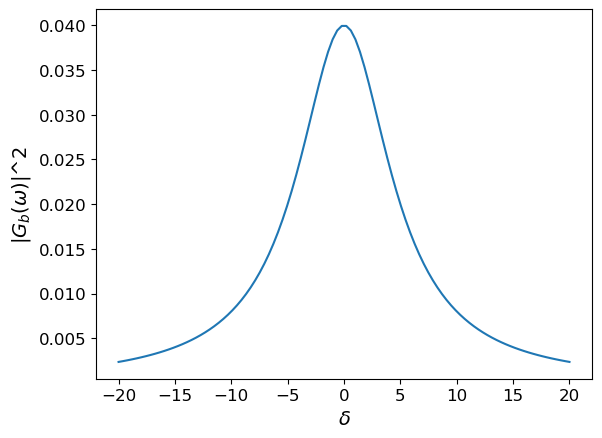

In [14]:
# Plot
plt.plot(δ, np.abs(Gb)**2)
plt.xlabel("$\\delta$")
plt.ylabel("$|G_b(\\omega)$|^2")

I think that this is different though.  If we used an eigenstate with $n$ photons, the eigenenergy would be $E_n=n\omega_c$, and we wouldn't get the same curve unless we accounted for this in defining the detuning.

Now let's try to calculate $G_{kl}(z) = \langle\phi_k|G(z)|\phi_l\rangle$ for the eigenstates of a system with a single atom.  This should allow us to effectively calculate the probability of ending up in $|\phi_k\rangle$ given we start in $|\phi_l\rangle$, which should be related to the transmission of the system.  This is effectively what we did when we were trying to use perturbation theory, and it seems that this is what they're doing in the Kurucz paper.  In their case, however, they only have one eigenstate corresponding to the cavity $|1, 0, \cdots, 0\rangle$.  Here, we have to consider ending up in $|1, 0\rangle$ or $|1, 1\rangle$.

For reference, we are using Eq. (A.25) in Ch. 3 of the Cohen-Tannoudji book and so $G_{kl}(z) = \frac{1}{z-E_k}\delta_{kl} + \frac{1}{z-E_k}V_{kl}\frac{1}{z-E_l} + \sum_i \frac{1}{z-E_k}V_{ki}\frac{1}{z-E_i}V_{il}\frac{1}{z-E_l} + \cdots$.  We will start by considering only up to the third term and note that we will probably have to show that this doesn't introduce too much error later.

In [40]:
def Gkl(z, Ek, ϕk, El, ϕl, H_eig, V):
    """
    Function for calculating the kl-th matrix element of G(z) using Eq. (A.25) of Ch. 3 of the C-T textbook
    :param z:     the complex argument
    :param ϕk:    eigenstate 1
    :param Ek:    eigenvalue of state 1
    :param ϕl:    eigenstate 2
    :param El:    eigenvalue of state 2
    :param H_eig: the other eigenstates of H0
    :param V:     the perturbation matrix
    :return:      array of the values of G_kl as z varies
    """
    # Calculate the first term
    first_term = np.zeros(z.shape[0], dtype=complex)
    for i in range(z.shape[0]):
        first_term[i] = 1 / (z[i] - Ek) * ϕk.dag() * ϕl
    
    # Calculate the second term
    snd_term = np.zeros(z.shape[0], dtype=complex)
    for i in range(z.shape[0]):
        snd_term[i] = 1 / (z[i] - Ek) * ϕk.dag() * V * ϕl * 1 / (z[i] - El)

    # Calculate the third term
    thrd_term = np.zeros(z.shape[0], dtype=complex)
    for i in range(z.shape[0]):
        thrd_term[i] = np.sum([1/(z[i]-Ek) * ϕk.dag() * V * H_eig[1][i] * 1/(z[i]-H_eig[0][i]) * H_eig[1][i].dag() * V * ϕl * 1/(z[i]-El)
                         for i in range(H_eig[0].shape[0])])

    return first_term + snd_term + thrd_term

In [21]:
# Define the parameters for the Hamiltonian
g10 = 10
g21 = 1
Δ1 = 0.1
ω21 = 5
ωc = 5
κ = 1
γ21 = 0.05
γ10 = 1

In [22]:
# Define the operators
a = qu.destroy(2)

σ10 = qu.Qobj([[0, 1, 0],
               [0, 0, 0],
               [0, 0, 0]])
σ21 = qu.Qobj([[0, 0, 0],
               [0, 0, 1],
               [0, 0, 0]])

In [24]:
# Define the Hamiltonian parts
Hc = (ωc - 1j*κ) * a.dag() * a
Ha = (-Δ1 - 1j*γ10) * σ10.dag() * σ10 + (ω21 - Δ1 - 1j*γ21) * σ21.dag() * σ21 + g10 * (σ10.dag() + σ10)
H0 = qu.tensor(Hc, qu.qeye(3)) + qu.tensor(qu.qeye(2), Ha)
H0

Quantum object: dims=[[2, 3], [2, 3]], shape=(6, 6), type='oper', dtype=Dia, isherm=False
Qobj data =
[[ 0. +0.j   10. +0.j    0. +0.j    0. +0.j    0. +0.j    0. +0.j  ]
 [10. +0.j   -0.1-1.j    0. +0.j    0. +0.j    0. +0.j    0. +0.j  ]
 [ 0. +0.j    0. +0.j    4.9-0.05j  0. +0.j    0. +0.j    0. +0.j  ]
 [ 0. +0.j    0. +0.j    0. +0.j    5. -1.j   10. +0.j    0. +0.j  ]
 [ 0. +0.j    0. +0.j    0. +0.j   10. +0.j    4.9-2.j    0. +0.j  ]
 [ 0. +0.j    0. +0.j    0. +0.j    0. +0.j    0. +0.j    9.9-1.05j]]

In [32]:
# Define the perturbation
V = g21 * (qu.tensor(a, σ21.dag()) + qu.tensor(a.dag(), σ21))
V

Quantum object: dims=[[2, 3], [2, 3]], shape=(6, 6), type='oper', dtype=Dia, isherm=True
Qobj data =
[[0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]]

In [26]:
# Get the eigenstates of H0
H0_eigs = H0.eigenstates()

Now because $H_0 = H_c \otimes I_a + I_c \otimes H_a$, we know that its eigenstates are tensor product combinations of the eigenstates of $H_c$ and $H_a$.  The eigenstates of $H_c$ are simple because its diagonal in the cavity basis and are $|0\rangle$ and $|1\rangle$.  The eigenstates of $H_a$ are a bit more involved, but we can get them easily.

In [28]:
# Get the eigenstates of Hc and Ha
Hc_eigs = Hc.eigenstates()
Ha_eigs = Ha.eigenstates()
Ha_eigs

(array([-10.03761765-0.5025031j,   4.9       -0.05j     ,
          9.93761765-0.4974969j]),
 array([Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
        Qobj data =
        [[-0.7044524 +0.03526629j]
         [ 0.70887453+0.j        ]
         [ 0.        +0.j        ]]                                           ,
        Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
        Qobj data =
        [[0.]
         [0.]
         [1.]]                                                                ,
        Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
        Qobj data =
        [[ 0.70887453+0.j        ]
         [ 0.7044524 -0.03526629j]
         [-0.        +0.j        ]]                                           ],
       dtype=object))

The atomic excitation states are such that $|0\rangle = (1, 0, 0), |1\rangle = (0, 1, 0)$, and $|2\rangle = (0, 0, 1)$ in the computational basis.  That means that looking at the above, we can see that we get 2 eigenstates that are linear combinations of $|0\rangle$ and $|1\rangle$ and one that is just $|2\rangle$.  We're interested in the probability of ending up with the photon in the cavity and the atom in either $|0\rangle$ or $|1\rangle$ from what I can determine.  If we define $|\phi_l\rangle = |n, \epsilon_m\rangle$, where $m=(0,1,2)$ denotes the index in the array of the eigenstates of $H_a$, we want $n=1, m=0,2$.

In [29]:
# Define the eigenstates we want to look at
ϕ10 = qu.tensor(Hc_eigs[1][1], Ha_eigs[1][0])
E10 = Hc_eigs[0][1] + Ha_eigs[0][0]
ϕ12 = qu.tensor(Hc_eigs[1][1], Ha_eigs[1][2])
E12 = Hc_eigs[0][1] + Ha_eigs[0][2]

In [30]:
# Define our complex argument
ω = np.linspace(-50, 50, 500)

In [43]:
# Calculate the transfer function
G1010 = Gkl(ω, E10, ϕ10, E10, ϕ10, H0_eigs, V)
G1012 = Gkl(ω, E10, ϕ10, E12, ϕ12, H0_eigs, V)
G1210 = Gkl(ω, E12, ϕ12, E10, ϕ10, H0_eigs, V)
G1212 = Gkl(ω, E12, ϕ12, E12, ϕ12, H0_eigs, V)

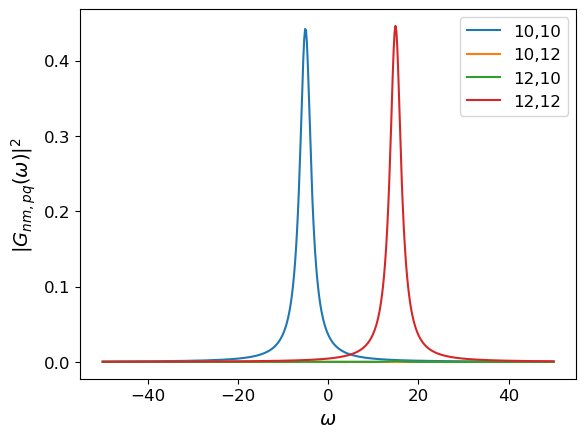

In [48]:
plt.plot(ω, np.abs(G1010) ** 2, label="10,10")
plt.plot(ω, np.abs(G1012) ** 2, label="10,12")
plt.plot(ω, np.abs(G1210) ** 2, label="12,10")
plt.plot(ω, np.abs(G1212) ** 2, label="12,12")
plt.xlabel("$\\omega$")
plt.ylabel("$|G_{nm,pq}(\\omega)|^2$")
plt.legend()